<a href="https://colab.research.google.com/github/sitahlango-maker/Financial_Inclusion/blob/main/cleanfinancialinclusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Financial Inclusion Prediction System
## Cleaned up  revised notebook

This notebook implements a clean, reproducible machine learning pipeline for predicting digital financial inclusion across Kenya, Tanzania and Uganda.

The notebook keeps the final artefact naming convention aligned with the web application:

- `pooled_model`
- `harmonized_model`
- `expert_models`
- `routing_model`
- `get_model_probabilities`
- `model_probability_columns`
- `router_feature_columns`

In [ ]:
#  INSTALL AND IMPORT LIBRARIES
import os
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
#  MOUNT GOOGLE DRIVE AND DEFINE PATHS
drive.mount("/content/drive")

MODEL_PATH = "/content/drive/MyDrive/Financial_Inclusion_Models"
os.makedirs(MODEL_PATH, exist_ok=True)

print("Model path:", MODEL_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model path: /content/drive/MyDrive/Financial_Inclusion_Models


## Load Final Combined Dataset

The final combined dataset contains Global Findex micro-level survey data enriched with macro-level mobile money and regulatory indicators.

In [ ]:
# LOAD FINAL COMBINED DATASET

DATA_URL = (
    "https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/"
    "main/Colab%20Notebooks/FinancialInclution/final_combined_data.csv"
)

df = pd.read_csv(DATA_URL)

# Standardise country codes
df["country_code"] = df["country_code"].astype(str).str.strip().str.upper()

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (3000, 20)


,country_code,female,age,educ,inc_q,urbanicity,account_mob,dig_account,anydigpayment,internet_use,wgt,mmpi_2023,reg_index,reg_cons_prot,reg_kyc_prop,reg_entry_lim,reg_max_lim,reg_agent_el,num_providers,earliest_launch
0,KEN,1,25,2.0000,1,1,1,1,1,1,0.7233,Very high,88.0000,100.0000,0,100,100,100,4,2007
1,KEN,1,26,2.0000,4,1,1,1,1,1,0.3314,Very high,88.0000,100.0000,0,100,100,100,4,2007
2,KEN,1,21,2.0000,3,1,1,1,1,1,1.0713,Very high,88.0000,100.0000,0,100,100,100,4,2007
3,KEN,1,25,2.0000,5,1,1,1,1,1,0.6770,Very high,88.0000,100.0000,0,100,100,100,4,2007
4,KEN,2,31,3.0000,5,2,1,1,1,1,0.4577,Very high,88.0000,100.0000,0,100,100,100,4,2007


In [ ]:
# DATA AUDIT
print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nCountry Distribution:")
print(df["country_code"].value_counts())

print("\nTarget Distribution (dig_account):")
print(df["dig_account"].value_counts(dropna=False))

print("\nData Types:")
print(df.dtypes)

DATASET INFORMATION

Dataset Shape:
(3000, 20)

Columns:
['country_code', 'female', 'age', 'educ', 'inc_q', 'urbanicity', 'account_mob', 'dig_account', 'anydigpayment', 'internet_use', 'wgt', 'mmpi_2023', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el', 'num_providers', 'earliest_launch']

Missing Values:
country_code       0
female             0
age                0
educ               3
inc_q              0
urbanicity         0
account_mob        0
dig_account        0
anydigpayment      0
internet_use       0
wgt                0
mmpi_2023          0
reg_index          0
reg_cons_prot      0
reg_kyc_prop       0
reg_entry_lim      0
reg_max_lim        0
reg_agent_el       0
num_providers      0
earliest_launch    0
dtype: int64

Duplicate Records:
56

Country Distribution:
country_code
KEN    1000
TZA    1000
UGA    1000
Name: count, dtype: int64

Target Distribution (dig_account):
dig_account
1    2282
0     718
Name: count, dtype: int64


##  Preprocessing Pipeline

The target variable is `dig_account`.

The following variables are removed before model training because they would introduce target leakage:

- `account_mob`
- `anydigpayment`
- `digital_payment` if present

In [ ]:
#  PREPROCESSING PIPELINE
TARGET = "dig_account"

LEAKAGE_COLUMNS = [
    "account_mob",
    "anydigpayment",
    "digital_payment"
]

COUNTRIES = ["KEN", "TZA", "UGA"]

def preprocess_data(df):
    data = df.copy()

    # Remove leakage variables
    data = data.drop(columns=LEAKAGE_COLUMNS, errors="ignore")

    # Target
    y = data[TARGET].astype(int)

    # Preserve original country labels for expert training and evaluation
    country = data["country_code"].astype(str).str.strip().str.upper()

    # Features
    X = data.drop(columns=[TARGET])

    # One-hot encode categorical variables
    X = pd.get_dummies(X, drop_first=False, dtype=np.uint8)

    # Fill missing values
    X = X.fillna(0)

    # Save feature columns
    feature_columns = X.columns.tolist()
    joblib.dump(feature_columns, os.path.join(MODEL_PATH, "feature_columns.joblib"))
    joblib.dump(feature_columns, os.path.join(MODEL_PATH, "feature_names.joblib"))

    return X, y, country

X, y, country = preprocess_data(df)

print("=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)
print("Feature Matrix:", X.shape)
print("Target Shape:", y.shape)
print("\nCountry Distribution:")
print(country.value_counts())

print("\nLeakage check:")
print("dig_account in X:", "dig_account" in X.columns)
print("account_mob in X:", "account_mob" in X.columns)
print("anydigpayment in X:", "anydigpayment" in X.columns)

print("\nFeature columns saved.")

PREPROCESSING COMPLETE
Feature Matrix: (3000, 19)
Target Shape: (3000,)

Country Distribution:
country_code
KEN    1000
TZA    1000
UGA    1000
Name: count, dtype: int64

Leakage check:
dig_account in X: False
account_mob in X: False
anydigpayment in X: False

Feature columns saved.


In [ ]:
# TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

country_train = country.loc[X_train.index]
country_test = country.loc[X_test.index]

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

print("\nCountry distribution in train:")
print(country_train.value_counts())

print("\nCountry distribution in test:")
print(country_test.value_counts())

Training samples: 2400
Testing samples : 600

Training target distribution:
dig_account
1   0.7608
0   0.2392
Name: proportion, dtype: float64

Testing target distribution:
dig_account
1   0.7600
0   0.2400
Name: proportion, dtype: float64

Country distribution in train:
country_code
TZA    815
KEN    801
UGA    784
Name: count, dtype: int64

Country distribution in test:
country_code
UGA    216
KEN    199
TZA    185
Name: count, dtype: int64


In [ ]:
# HELPER FUNCTIONS

def evaluate_model(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob)
    }

def align_features(X_data, model):
    if hasattr(model, "feature_names_in_"):
        return X_data.reindex(columns=model.feature_names_in_, fill_value=0)
    return X_data

def make_xgb_model():
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    )

print("Helper functions defined.")

Helper functions defined.


## Train Pooled XGBoost Model

The pooled model is the base model trained on all countries combined.

In [ ]:
# TRAIN POOLED MODEL

pooled_model = make_xgb_model()
pooled_model.fit(X_train, y_train)

pooled_pred = pooled_model.predict(X_test)
pooled_prob = pooled_model.predict_proba(X_test)[:, 1]

pooled_metrics = evaluate_model("Pooled", y_test, pooled_pred, pooled_prob)

print("Pooled model trained successfully.")
print(pooled_metrics)

joblib.dump(pooled_model, os.path.join(MODEL_PATH, "pooled_model.joblib"))
print("Saved pooled_model.joblib")

Pooled model trained successfully.
{'Model': 'Pooled', 'Accuracy': 0.76, 'Precision': 0.8170731707317073, 'Recall': 0.881578947368421, 'F1': 0.8481012658227848, 'ROC_AUC': np.float64(0.8106115984405456)}
Saved pooled_model.joblib


## Train Harmonized XGBoost Model

The harmonized model uses balanced country-level observations through random undersampling.

In [ ]:
# CREATE HARMONIZED TRAINING DATA
train_data = X_train.copy()
train_data["target"] = y_train
train_data["country"] = country_train.values

min_country_count = train_data["country"].value_counts().min()

harmonized_train = (
    train_data
    .groupby("country", group_keys=False)
    .apply(lambda x: x.sample(min_country_count, random_state=42))
)

X_train_harmonized = harmonized_train.drop(columns=["target", "country"])
y_train_harmonized = harmonized_train["target"]

print("Harmonized training distribution:")
print(harmonized_train["country"].value_counts())

Harmonized training distribution:
country
KEN    784
TZA    784
UGA    784
Name: count, dtype: int64


In [ ]:
# TRAIN HARMONIZED MODEL

harmonized_model = make_xgb_model()
harmonized_model.fit(X_train_harmonized, y_train_harmonized)

harm_pred = harmonized_model.predict(X_test)
harm_prob = harmonized_model.predict_proba(X_test)[:, 1]

harmonized_metrics = evaluate_model("Harmonized", y_test, harm_pred, harm_prob)

print("Harmonized model trained successfully.")
print(harmonized_metrics)

joblib.dump(harmonized_model, os.path.join(MODEL_PATH, "harmonized_model.joblib"))
print("Saved harmonized_model.joblib")

Harmonized model trained successfully.
{'Model': 'Harmonized', 'Accuracy': 0.7583333333333333, 'Precision': 0.811623246492986, 'Recall': 0.8881578947368421, 'F1': 0.8481675392670157, 'ROC_AUC': np.float64(0.8132157651072125)}
Saved harmonized_model.joblib


## 10. Train Country-Specific Expert Models

Each expert model is trained only on observations from one country.

In [ ]:
#  TRAIN COUNTRY-SPECIFIC EXPERT MODELS

def train_country_expert(country_name, X_train, y_train, country_train):
    print(f"\nTraining {country_name} expert...")

    mask = country_train.astype(str).str.upper().values == country_name

    X_country = X_train.loc[mask].copy()
    y_country = y_train.loc[mask].copy()

    print(f"{country_name} samples:", X_country.shape)

    expert_model = make_xgb_model()
    expert_model.fit(X_country, y_country)

    save_path = os.path.join(MODEL_PATH, f"expert_model_{country_name}.joblib")
    joblib.dump(expert_model, save_path)

    print(f"Saved expert_model_{country_name}.joblib")
    return expert_model

expert_models = {}

for c in COUNTRIES:
    expert_models[c] = train_country_expert(c, X_train, y_train, country_train)

print("\nAll expert models trained and saved.")
print(expert_models.keys())


Training KEN expert...
KEN samples: (801, 19)
Saved expert_model_KEN.joblib

Training TZA expert...
TZA samples: (815, 19)
Saved expert_model_TZA.joblib

Training UGA expert...
UGA samples: (784, 19)
Saved expert_model_UGA.joblib

All expert models trained and saved.
dict_keys(['KEN', 'TZA', 'UGA'])


In [ ]:
#  EVALUATE COUNTRY-SPECIFIC EXPERT MODELS

expert_results = []

country_test_clean = country_test.astype(str).str.strip().str.upper()

for c in COUNTRIES:
    mask = country_test_clean == c
    n = mask.sum()

    print(f"{c} test samples:", n)

    if n == 0:
        print(f"Skipping Expert_{c} because there are no test samples.")
        continue

    X_country_test = X_test.loc[mask]
    y_country_test = y_test.loc[mask]

    pred = expert_models[c].predict(X_country_test)
    prob = expert_models[c].predict_proba(X_country_test)[:, 1]

    expert_results.append({
        "Model": f"Expert_{c}",
        "Samples": n,
        "Accuracy": accuracy_score(y_country_test, pred),
        "Precision": precision_score(y_country_test, pred, zero_division=0),
        "Recall": recall_score(y_country_test, pred, zero_division=0),
        "F1": f1_score(y_country_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_country_test, prob)
    })

expert_results_df = pd.DataFrame(expert_results)
display(expert_results_df)

KEN test samples: 199
TZA test samples: 185
UGA test samples: 216


,Model,Samples,Accuracy,Precision,Recall,F1,ROC_AUC
0,Expert_KEN,199,0.8844,0.9058,0.9719,0.9377,0.7528
1,Expert_TZA,185,0.6324,0.6750,0.7364,0.7043,0.7207
2,Expert_UGA,216,0.7269,0.8079,0.8512,0.8290,0.7140


In [ ]:
# MODEL COMPARISON BEFORE ROUTING

comparison_results = []

comparison_results.append(pooled_metrics)
comparison_results.append(harmonized_metrics)

for c in COUNTRIES:
    mask = country_test_clean == c

    X_country_test = X_test.loc[mask]
    y_country_test = y_test.loc[mask]

    expert_pred = expert_models[c].predict(X_country_test)
    expert_prob = expert_models[c].predict_proba(X_country_test)[:, 1]

    comparison_results.append(
        evaluate_model(
            f"Expert_{c}",
            y_country_test,
            expert_pred,
            expert_prob
        )
    )

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

display(comparison_df)

joblib.dump(comparison_df, os.path.join(MODEL_PATH, "model_comparison_results.joblib"))
comparison_df.to_csv(os.path.join(MODEL_PATH, "model_comparison_results.csv"), index=False)

print("Saved model_comparison_results.joblib and model_comparison_results.csv")

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Expert_KEN,0.8844,0.9058,0.9719,0.9377,0.7528
1,Pooled,0.7600,0.8171,0.8816,0.8481,0.8106
2,Harmonized,0.7583,0.8116,0.8882,0.8482,0.8132
3,Expert_UGA,0.7269,0.8079,0.8512,0.8290,0.7140
4,Expert_TZA,0.6324,0.6750,0.7364,0.7043,0.7207


Saved model_comparison_results.joblib and model_comparison_results.csv


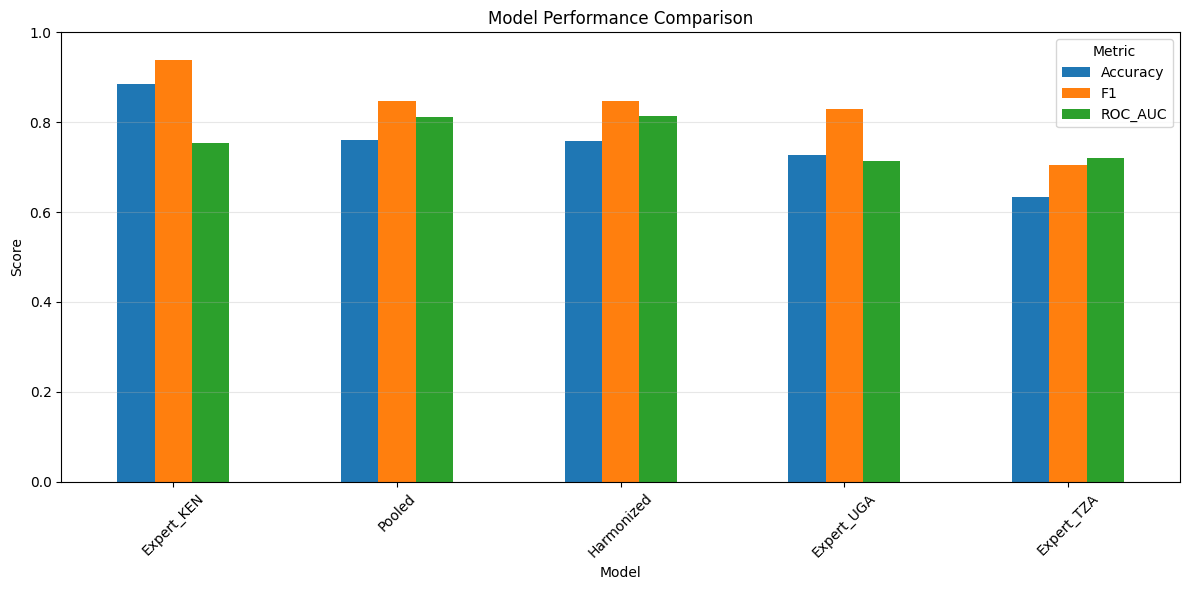

Saved chart: /content/drive/MyDrive/Financial_Inclusion_Models/model_comparison_chart.png


In [ ]:
#  PLOT MODEL COMPARISON

metrics_df = comparison_df[["Model", "Accuracy", "F1", "ROC_AUC"]].set_index("Model")

ax = metrics_df.plot(kind="bar", figsize=(12, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Metric")
plt.xticks(rotation=45)
plt.tight_layout()

model_comparison_chart = os.path.join(MODEL_PATH, "model_comparison_chart.png")
plt.savefig(model_comparison_chart, dpi=300, bbox_inches="tight")
plt.show()

print("Saved chart:", model_comparison_chart)

##  Feature Importance Comparison

In [ ]:
# FEATURE IMPORTANCE COMPARISON

def get_feature_importance_df(model, model_name, feature_names, top_n=10):
    fi = pd.DataFrame({
        "Model": model_name,
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    return fi.sort_values(by="Importance", ascending=False).head(top_n)

all_fi_tables = []

all_fi_tables.append(
    get_feature_importance_df(pooled_model, "Pooled", X_train.columns, top_n=10)
)

all_fi_tables.append(
    get_feature_importance_df(harmonized_model, "Harmonized", X_train.columns, top_n=10)
)

for c in COUNTRIES:
    all_fi_tables.append(
        get_feature_importance_df(
            expert_models[c],
            f"Expert_{c}",
            X_train.columns,
            top_n=10
        )
    )

feature_impact_df = pd.concat(all_fi_tables, ignore_index=True)

display(feature_impact_df)

joblib.dump(feature_impact_df, os.path.join(MODEL_PATH, "feature_impact_table.joblib"))
feature_impact_df.to_csv(os.path.join(MODEL_PATH, "feature_impact_table.csv"), index=False)

print("Saved feature_impact_table.joblib and feature_impact_table.csv")

,Model,Feature,Importance
0,Pooled,internet_use,0.4547
1,Pooled,reg_kyc_prop,0.1391
2,Pooled,educ,0.0635
3,Pooled,num_providers,0.0578
4,Pooled,age,0.0489
5,Pooled,inc_q,0.0465
6,Pooled,reg_cons_prot,0.0415
7,Pooled,wgt,0.0404
8,Pooled,urbanicity,0.0385
9,Pooled,reg_index,0.0361


Saved feature_impact_table.joblib and feature_impact_table.csv


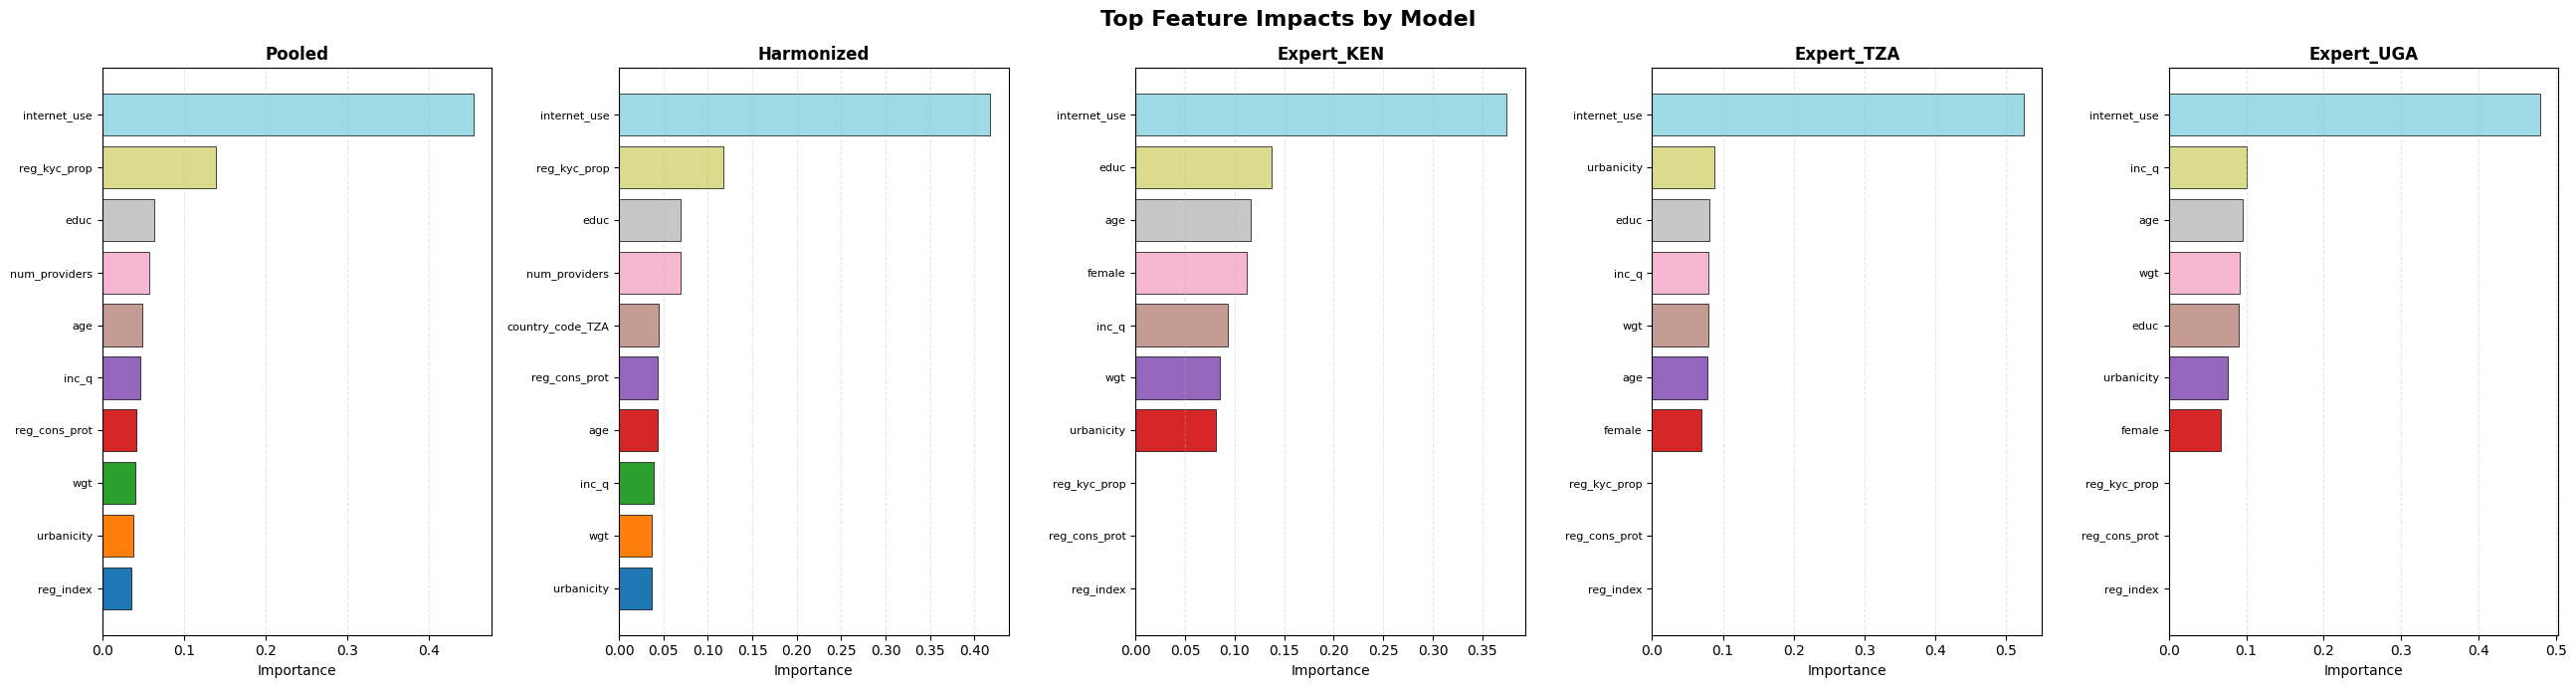

Saved feature impact chart: /content/drive/MyDrive/Financial_Inclusion_Models/feature_impact_comparison.png


In [ ]:
# PLOT FEATURE IMPORTANCE COMPARISON

import numpy as np

model_order = [
    "Pooled",
    "Harmonized",
    "Expert_KEN",
    "Expert_TZA",
    "Expert_UGA"
]

fig, axes = plt.subplots(
    1,
    len(model_order),
    figsize=(26, 7),
    sharex=False
)

for ax, model_name in zip(axes, model_order):

    temp = feature_impact_df[
        feature_impact_df["Model"] == model_name
    ].sort_values(by="Importance", ascending=True)

    # Generate a unique color for each feature
    colors = plt.cm.tab20(
        np.linspace(0, 1, len(temp))
    )

    ax.barh(
        temp["Feature"],
        temp["Importance"],
        color=colors,
        edgecolor="black",
        linewidth=0.5
    )

    ax.set_title(model_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance")
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.suptitle(
    "Top Feature Impacts by Model",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

figure_path = os.path.join(
    MODEL_PATH,
    "feature_impact_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved feature impact chart:", figure_path)

## 12. Build Model Probabilities

The routing model uses both the original input features and the probability outputs from the base and expert models.

In [ ]:
# BUILD MODEL PROBABILITY OUTPUTS

def get_model_probabilities(X_data):
    probs = pd.DataFrame(index=X_data.index)

    probs["Pooled"] = pooled_model.predict_proba(X_data)[:, 1]
    probs["Harmonized"] = harmonized_model.predict_proba(X_data)[:, 1]

    for c in COUNTRIES:
        probs[f"Expert_{c}"] = expert_models[c].predict_proba(X_data)[:, 1]

    return probs

train_model_probs = get_model_probabilities(X_train)
test_model_probs = get_model_probabilities(X_test)

display(train_model_probs.head())

joblib.dump(
    train_model_probs.columns.tolist(),
    os.path.join(MODEL_PATH, "model_probability_columns.joblib")
)

print("Saved model_probability_columns.joblib")

,Pooled,Harmonized,Expert_KEN,Expert_TZA,Expert_UGA
335,0.9842,0.9855,0.9967,0.9579,0.6964
2739,0.2439,0.3178,0.9604,0.2440,0.0929
1353,0.2781,0.2114,0.9914,0.2345,0.0625
1630,0.9919,0.9922,0.9901,0.9916,0.9920
244,0.2870,0.3222,0.2429,0.1844,0.2679


Saved model_probability_columns.joblib


## Train Routing Model

The routing model learns which model is expected to provide the most reliable prediction for each profile.  
Routing labels are created by identifying the model with the smallest absolute prediction error for each observation.

In [ ]:
# BUILD ROUTING LABELS

def build_routing_labels(model_probs, y_true):
    labels = []

    for idx in model_probs.index:
        true_value = y_true.loc[idx]
        errors = abs(model_probs.loc[idx] - true_value)
        best_model = errors.idxmin()
        labels.append(best_model)

    return pd.Series(labels, index=model_probs.index)

routing_labels_train = build_routing_labels(train_model_probs, y_train)
routing_labels_test = build_routing_labels(test_model_probs, y_test)

print("Routing label distribution:")
print(routing_labels_train.value_counts())

Routing label distribution:
Expert_KEN    1328
Expert_UGA     429
Expert_TZA     420
Pooled         119
Harmonized     104
Name: count, dtype: int64


In [ ]:
# TRAIN ROUTING MODE

router_X_train = pd.concat([X_train, train_model_probs], axis=1)
router_X_test = pd.concat([X_test, test_model_probs], axis=1)

routing_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

routing_model.fit(router_X_train, routing_labels_train)

router_pred = routing_model.predict(router_X_test)

router_accuracy = accuracy_score(routing_labels_test, router_pred)

print("Routing model trained successfully.")
print("Router classes:", routing_model.classes_)
print("Router Accuracy:", router_accuracy)

print("\nRouting Classification Report:")
print(classification_report(routing_labels_test, router_pred))

joblib.dump(routing_model, os.path.join(MODEL_PATH, "routing_model.joblib"))
joblib.dump(router_X_train.columns.tolist(), os.path.join(MODEL_PATH, "router_feature_columns.joblib"))

print("Saved routing_model.joblib")
print("Saved router_feature_columns.joblib")

Routing model trained successfully.
Router classes: ['Expert_KEN' 'Expert_TZA' 'Expert_UGA' 'Harmonized' 'Pooled']
Router Accuracy: 0.6166666666666667

Routing Classification Report:
              precision    recall  f1-score   support

  Expert_KEN       0.69      0.81      0.74       323
  Expert_TZA       0.45      0.43      0.44        98
  Expert_UGA       0.51      0.58      0.54        90
  Harmonized       0.50      0.03      0.05        37
      Pooled       0.59      0.25      0.35        52

    accuracy                           0.62       600
   macro avg       0.55      0.42      0.43       600
weighted avg       0.60      0.62      0.59       600

Saved routing_model.joblib
Saved router_feature_columns.joblib


##  Final Hybrid / Mixture of Experts Prediction

In [ ]:
# FINAL MOE PREDICTION

selected_models = pd.Series(router_pred, index=X_test.index)

moe_probs = []

for idx in X_test.index:
    selected_model = selected_models.loc[idx]
    prob = test_model_probs.loc[idx, selected_model]
    moe_probs.append(prob)

moe_probs = np.array(moe_probs)
moe_pred = (moe_probs >= 0.5).astype(int)

moe_metrics = {
    "Model": "MoE_Router",
    "Accuracy": accuracy_score(y_test, moe_pred),
    "Precision": precision_score(y_test, moe_pred, zero_division=0),
    "Recall": recall_score(y_test, moe_pred, zero_division=0),
    "F1": f1_score(y_test, moe_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, moe_probs)
}

print("MoE Metrics:")
print(moe_metrics)

print("\nRouting Statistics:")
print(selected_models.value_counts())

MoE Metrics:
{'Model': 'MoE_Router', 'Accuracy': 0.7516666666666667, 'Precision': 0.8139059304703476, 'Recall': 0.8728070175438597, 'F1': 0.8423280423280424, 'ROC_AUC': np.float64(0.7292275828460039)}

Routing Statistics:
Expert_KEN    381
Expert_UGA    102
Expert_TZA     93
Pooled         22
Harmonized      2
Name: count, dtype: int64


In [ ]:
#  FINAL MODEL COMPARISON

final_comparison_df = pd.concat(
    [
        comparison_df,
        pd.DataFrame([moe_metrics])
    ],
    ignore_index=True
)

final_comparison_df = final_comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(final_comparison_df)

joblib.dump(final_comparison_df, os.path.join(MODEL_PATH, "final_model_comparison.joblib"))
final_comparison_df.to_csv(os.path.join(MODEL_PATH, "final_model_comparison.csv"), index=False)

print("Saved final_model_comparison.joblib and final_model_comparison.csv")

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Expert_KEN,0.8844,0.9058,0.9719,0.9377,0.7528
1,Pooled,0.7600,0.8171,0.8816,0.8481,0.8106
2,Harmonized,0.7583,0.8116,0.8882,0.8482,0.8132
3,MoE_Router,0.7517,0.8139,0.8728,0.8423,0.7292
4,Expert_UGA,0.7269,0.8079,0.8512,0.8290,0.7140
5,Expert_TZA,0.6324,0.6750,0.7364,0.7043,0.7207


Saved final_model_comparison.joblib and final_model_comparison.csv


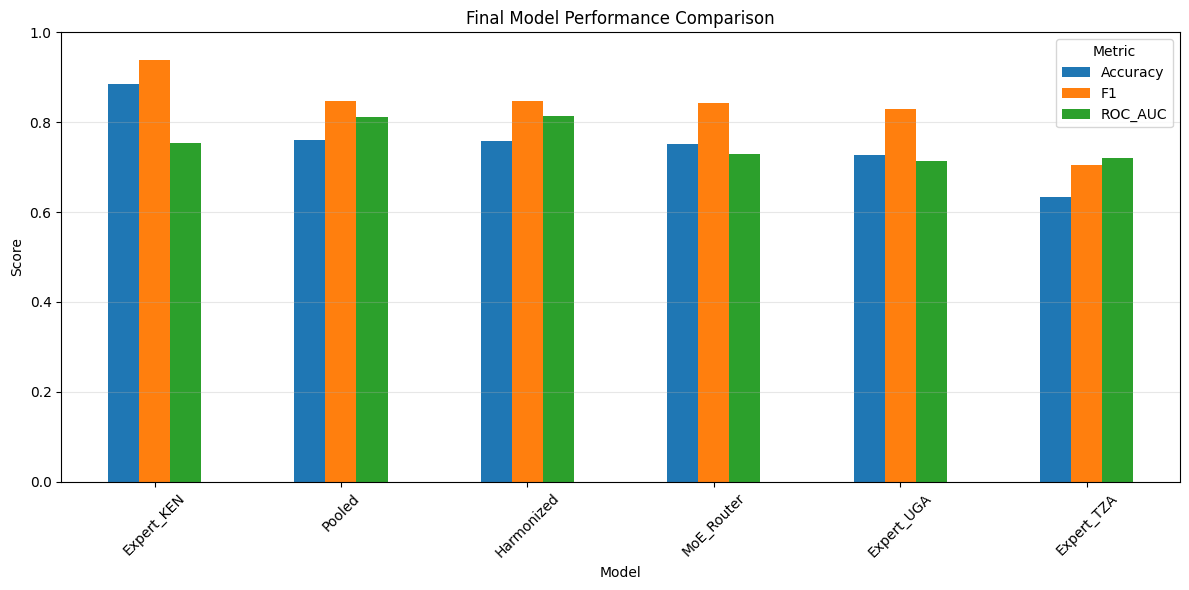

Saved chart: /content/drive/MyDrive/Financial_Inclusion_Models/final_model_comparison_chart.png


In [ ]:
#  FINAL MODEL COMPARISON CHART

metrics_df = final_comparison_df[
    ["Model", "Accuracy", "F1", "ROC_AUC"]
].set_index("Model")

ax = metrics_df.plot(kind="bar", figsize=(12, 6))

plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Metric")
plt.xticks(rotation=45)
plt.tight_layout()

chart_path = os.path.join(MODEL_PATH, "final_model_comparison_chart.png")
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved chart:", chart_path)

## Fairness Evaluation

The fairness evaluation compares model performance across gender and residence groups.

In [ ]:
# FAIRNESS EVALUATION

fairness_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": moe_pred,
    "y_prob": moe_probs,
    "female": df.loc[X_test.index, "female"],
    "urbanicity": df.loc[X_test.index, "urbanicity"]
})

# Clean and standardise group labels
fairness_df["Gender"] = fairness_df["female"].map({
    1: "Female",
    2: "Male"
})

fairness_df["Residence"] = fairness_df["urbanicity"].map({
    1: "Urban",
    2: "Rural"
})

def subgroup_metrics(data, group_col):
    rows = []

    for group_name, group_data in data.groupby(group_col):

        if group_data["y_true"].nunique() < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(
                group_data["y_true"],
                group_data["y_prob"]
            )

        rows.append({
            "Group": group_name,
            "Samples": len(group_data),
            "Accuracy": accuracy_score(
                group_data["y_true"],
                group_data["y_pred"]
            ),
            "F1 Score": f1_score(
                group_data["y_true"],
                group_data["y_pred"],
                zero_division=0
            ),
            "ROC-AUC": auc
        })

    return pd.DataFrame(rows)

gender_fairness_results = subgroup_metrics(
    fairness_df,
    "Gender"
)

residence_fairness_results = subgroup_metrics(
    fairness_df,
    "Residence"
)

print("Gender Fairness Results")
display(gender_fairness_results)

print("Residence Fairness Results")
display(residence_fairness_results)

gender_fairness_results.to_csv(
    os.path.join(MODEL_PATH, "gender_fairness_results.csv"),
    index=False
)

residence_fairness_results.to_csv(
    os.path.join(MODEL_PATH, "residence_fairness_results.csv"),
    index=False
)

print("Saved fairness result files.")

Gender Fairness Results


,Group,Samples,Accuracy,F1 Score,ROC-AUC
0,Female,325,0.7292,0.8167,0.7582
1,Male,275,0.7782,0.8688,0.6664


Residence Fairness Results


,Group,Samples,Accuracy,F1 Score,ROC-AUC
0,Rural,105,0.8476,0.9158,0.6830
1,Urban,495,0.7313,0.8238,0.7217


Saved fairness result files.


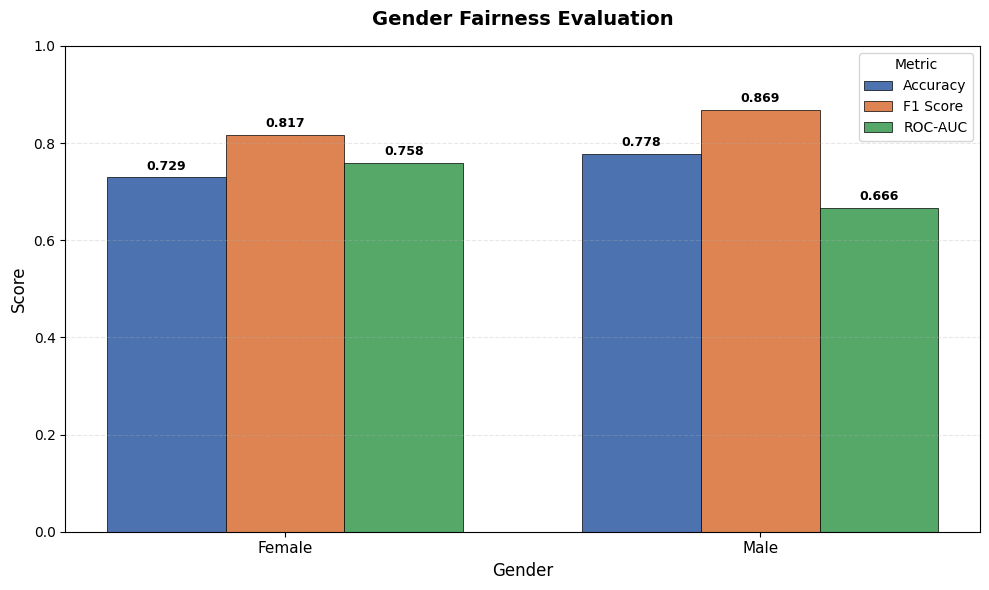

Saved: /content/drive/MyDrive/Financial_Inclusion_Models/gender_fairness_evaluation.png


In [ ]:
# GENDER FAIRNESS EVALUATION PLOT

import matplotlib.pyplot as plt
import numpy as np

# Ensure consistent ordering
gender_fairness_results = gender_fairness_results.sort_values("Group")

metrics = ["Accuracy", "F1 Score", "ROC-AUC"]

x = np.arange(len(gender_fairness_results))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

metric_colors = {
    "Accuracy": "#4C72B0",
    "F1 Score": "#DD8452",
    "ROC-AUC": "#55A868"
}

for i, metric in enumerate(metrics):

    bars = ax.bar(
        x + (i - 1) * width,
        gender_fairness_results[metric],
        width=width,
        label=metric,
        color=metric_colors[metric],
        edgecolor="black",
        linewidth=0.5
    )

    # Add value labels
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

ax.set_title(
    "Gender Fairness Evaluation",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Gender", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(
    gender_fairness_results["Group"],
    fontsize=11
)

ax.set_ylim(0, 1.0)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Metric",
    frameon=True
)

plt.tight_layout()

figure_path = os.path.join(
    MODEL_PATH,
    "gender_fairness_evaluation.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

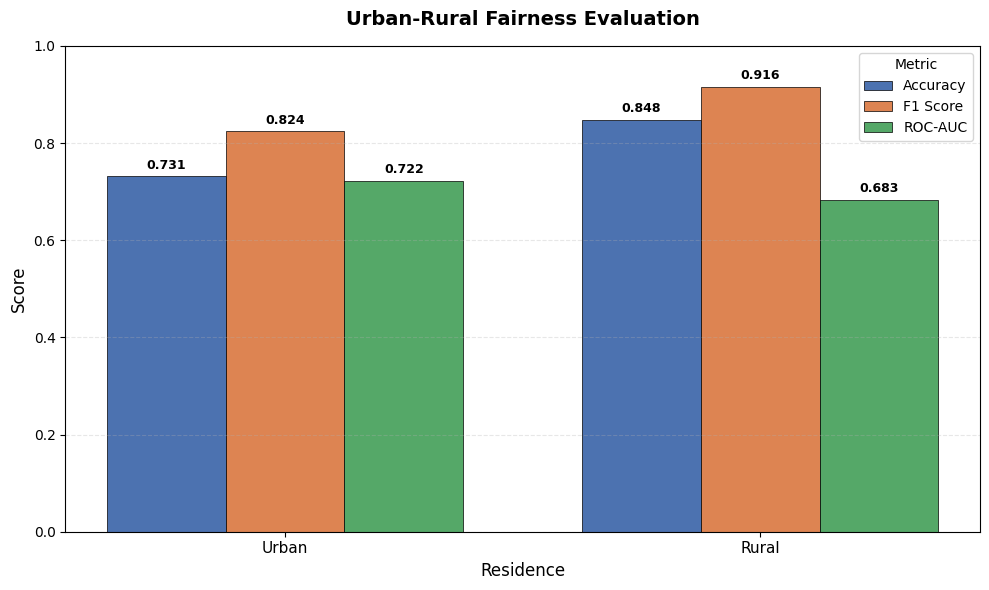

Saved: /content/drive/MyDrive/Financial_Inclusion_Models/urban_rural_fairness_evaluation.png


In [ ]:
# URBAN-RURAL FAIRNESS EVALUATION PLOT

import matplotlib.pyplot as plt
import numpy as np

# Ensure consistent ordering
residence_fairness_results["Group"] = pd.Categorical(
    residence_fairness_results["Group"],
    categories=["Urban", "Rural"],
    ordered=True
)

residence_fairness_results = residence_fairness_results.sort_values("Group")

metrics = ["Accuracy", "F1 Score", "ROC-AUC"]

x = np.arange(len(residence_fairness_results))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

metric_colors = {
    "Accuracy": "#4C72B0",
    "F1 Score": "#DD8452",
    "ROC-AUC": "#55A868"
}

for i, metric in enumerate(metrics):

    bars = ax.bar(
        x + (i - 1) * width,
        residence_fairness_results[metric],
        width=width,
        label=metric,
        color=metric_colors[metric],
        edgecolor="black",
        linewidth=0.5
    )

    # Add value labels
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

ax.set_title(
    "Urban-Rural Fairness Evaluation",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Residence", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(
    residence_fairness_results["Group"],
    fontsize=11
)

ax.set_ylim(0, 1.0)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Metric",
    frameon=True
)

plt.tight_layout()

figure_path = os.path.join(
    MODEL_PATH,
    "urban_rural_fairness_evaluation.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

##  Optional SHAP Explainability

This is optional and may take longer to run.

In [ ]:
# OPTIONAL SHAP EXPLAINABILITY

RUN_SHAP = False

if RUN_SHAP:
    !pip install shap -q

    import shap

    shap_sample = X_test.sample(min(200, len(X_test)), random_state=42)

    explainer = shap.TreeExplainer(pooled_model)
    shap_values = explainer.shap_values(shap_sample)

    shap.summary_plot(
        shap_values,
        shap_sample,
        plot_type="bar",
        show=False
    )

    plt.title("SHAP Feature Impact - Pooled Model")
    plt.tight_layout()

    shap_path = os.path.join(MODEL_PATH, "shap_feature_impact_pooled.png")
    plt.savefig(shap_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved SHAP chart:", shap_path)
else:
    print("SHAP skipped. Set RUN_SHAP = True to run this section.")

SHAP skipped. Set RUN_SHAP = True to run this section.


##  Save Final Artefacts

In [ ]:
# SAVE FINAL MODEL INFORMATION AND MEDIANS

medians = X_train.median(numeric_only=True).to_dict()

joblib.dump(medians, os.path.join(MODEL_PATH, "medians.joblib"))

model_info = {
    "models_saved": [
        "pooled_model",
        "harmonized_model",
        "expert_model_KEN",
        "expert_model_TZA",
        "expert_model_UGA",
        "routing_model"
    ],
    "support_files": [
        "feature_columns.joblib",
        "feature_names.joblib",
        "router_feature_columns.joblib",
        "model_probability_columns.joblib",
        "medians.joblib"
    ],
    "feature_count": len(X_train.columns),
    "countries": COUNTRIES,
    "target": TARGET,
    "leakage_columns_removed": LEAKAGE_COLUMNS,
    "date_saved": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")
}

joblib.dump(model_info, os.path.join(MODEL_PATH, "model_info.joblib"))

print("Saved medians.joblib")
print("Saved model_info.joblib")

Saved medians.joblib
Saved model_info.joblib


In [ ]:
#  FINAL ARTEFACT CHECK

required_files = [
    "feature_columns.joblib",
    "feature_names.joblib",
    "pooled_model.joblib",
    "harmonized_model.joblib",
    "expert_model_KEN.joblib",
    "expert_model_TZA.joblib",
    "expert_model_UGA.joblib",
    "routing_model.joblib",
    "router_feature_columns.joblib",
    "model_probability_columns.joblib",
    "medians.joblib",
    "model_info.joblib",
    "model_comparison_results.csv",
    "feature_impact_table.csv",
    "final_model_comparison.csv",
    "final_model_comparison_chart.png",
    "feature_impact_comparison.png",
    "gender_fairness_results.csv",
    "residence_fairness_results.csv"
]

print("CHECKING FILES\n")

for file in required_files:
    exists = os.path.exists(os.path.join(MODEL_PATH, file))
    print(f"{file:<45} {'✅' if exists else '❌'}")

CHECKING FILES

feature_columns.joblib                        ✅
feature_names.joblib                          ✅
pooled_model.joblib                           ✅
harmonized_model.joblib                       ✅
expert_model_KEN.joblib                       ✅
expert_model_TZA.joblib                       ✅
expert_model_UGA.joblib                       ✅
routing_model.joblib                          ✅
router_feature_columns.joblib                 ✅
model_probability_columns.joblib              ✅
medians.joblib                                ✅
model_info.joblib                             ✅
model_comparison_results.csv                  ✅
feature_impact_table.csv                      ✅
final_model_comparison.csv                    ✅
final_model_comparison_chart.png              ✅
feature_impact_comparison.png                 ✅
gender_fairness_results.csv                   ✅
residence_fairness_results.csv                ✅


##  Final Notes

This notebook intentionally removes duplicate experimental sections and keeps one clean end-to-end pipeline suitable for dissertation submission and artefact reproducibility.

Final training features exclude:

- `dig_account`
- `account_mob`
- `anydigpayment`
- `digital_payment` if present

Final artefacts align with the Streamlit application and dissertation terminology.